# 实验七之一：GAN 动漫人脸生成（本地运行版）

本 Notebook 在本地完成《GAN》3.2 节的动漫人脸生成任务：使用 DCGAN 学习动漫人脸分布，并从随机噪声生成新的 `64×64` RGB 动漫人脸。

实验与课件保持一致：

- 数据：读取与 Notebook 同目录下的 `faces`（当前共 71314 张 `96×96` 图片），缩放为 `64×64`，归一化到 `[-1, 1]`；
- 模型：`z_dim=100` 的 Generator 与 Discriminator；
- 训练：BCE 损失、Adam 优化器、`batch_size=64`、`lr=1e-4`；
- 输出：统一写入本地 `lab7-1/outputs`，包括每轮训练样例、模型 checkpoint、最终 100 张图片和 `images.tgz`。

课件演示实际运行 `1` 个 epoch，并把 `50` 标为更充分的训练设置。本 Notebook 默认运行 `1` 个 epoch，确认流程后可把 `N_EPOCHS` 改成 `50` 以提高生成质量。请使用已有的 `notebook` Conda 环境运行；无需安装 `qqdm`，代码使用 `tqdm` 显示进度。当前 Intel Mac 将使用 CPU，完整一轮会明显慢于云端 GPU。

In [6]:
import os
import random
import tarfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import make_grid, save_image
from tqdm.auto import tqdm

SEED = 2021

def same_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

same_seeds(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
KNOWN_LOCAL_DIR = Path("/Users/bob.li/Code/DL-ZJU/lab7-1")

def locate_project_dir():
    override = os.environ.get("LAB7_PROJECT_DIR")
    if override:
        return Path(override).expanduser().resolve()
    candidates = [Path.cwd(), Path.cwd() / "lab7-1", KNOWN_LOCAL_DIR]
    for candidate in candidates:
        if (candidate / "faces").is_dir() or (candidate / "data" / "faces").is_dir():
            return candidate.resolve()
    return KNOWN_LOCAL_DIR.resolve() if KNOWN_LOCAL_DIR.exists() else Path.cwd().resolve()

PROJECT_DIR = locate_project_dir()
OUTPUT_DIR = Path(os.environ.get("LAB7_OUTPUT_DIR", PROJECT_DIR / "outputs")).expanduser().resolve()
LOG_DIR = OUTPUT_DIR / "logs"
CKPT_DIR = OUTPUT_DIR / "checkpoints"
FINAL_DIR = OUTPUT_DIR / "output"
for directory in (LOG_DIR, CKPT_DIR, FINAL_DIR):
    directory.mkdir(parents=True, exist_ok=True)

FAST_DEV_RUN = os.environ.get("LAB7_FAST_DEV_RUN", "0") == "1"
USE_SYNTHETIC_DATA = os.environ.get("LAB7_USE_SYNTHETIC_DATA", "0") == "1"

print("PyTorch:", torch.__version__)
print("设备:", DEVICE)
print("实验目录:", PROJECT_DIR)
print("输出目录:", OUTPUT_DIR)
print("快速冒烟测试:", FAST_DEV_RUN)

PyTorch: 2.2.2
设备: cpu
实验目录: /Users/bob.li/Code/DL-ZJU/lab7-1
输出目录: /Users/bob.li/Code/DL-ZJU/lab7-1/outputs
快速冒烟测试: False


## 1. 定位并准备数据集

代码默认读取本地 `lab7-1/faces`，也兼容 `lab7-1/data/faces`。即使 Jupyter 的工作目录是 `/` 或仓库根目录，也会定位到当前实验目录；如以后移动数据，可用环境变量 `LAB7_INPUT_DIR` 指定新目录。

In [7]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def list_images(root):
    root = Path(root)
    if not root.exists():
        return []
    return sorted(path for path in root.rglob("*") if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS)

def create_synthetic_faces(root, count=16):
    root.mkdir(parents=True, exist_ok=True)
    generator = np.random.default_rng(SEED)
    yy, xx = np.mgrid[:64, :64]
    for index in range(count):
        background = generator.integers(150, 245, size=3, dtype=np.uint8)
        image = np.broadcast_to(background, (64, 64, 3)).copy()
        face = ((xx - 32) / 22) ** 2 + ((yy - 34) / 26) ** 2 <= 1
        image[face] = np.array([245, 205 + index % 20, 185], dtype=np.uint8)
        hair = face & (yy < 26 + index % 5)
        image[hair] = generator.integers(20, 130, size=3, dtype=np.uint8)
        image[29:34, 22:27] = (30, 45, 70)
        image[29:34, 38:43] = (30, 45, 70)
        Image.fromarray(image).save(root / f"face_{index:03d}.png")
    return root

def locate_image_root():
    override = os.environ.get("LAB7_INPUT_DIR")
    if override:
        candidates = [Path(override)]
    elif USE_SYNTHETIC_DATA:
        candidates = [create_synthetic_faces(OUTPUT_DIR / "synthetic_faces")]
    else:
        candidates = [
            PROJECT_DIR / "faces",
            PROJECT_DIR / "data" / "faces",
            Path.cwd() / "faces",
            Path.cwd() / "lab7-1" / "faces",
            KNOWN_LOCAL_DIR / "faces",
        ]

    checked = []
    for candidate in dict.fromkeys(Path(path).expanduser().resolve() for path in candidates):
        files = list_images(candidate)
        checked.append((candidate, len(files)))
        if files:
            return candidate, files

    details = "\n".join(f"- {path}: {count} 张" for path, count in checked)
    raise FileNotFoundError(
        "未找到本地动漫人脸图像。请把 faces 目录放在 lab7-1 下，"
        "或用 LAB7_INPUT_DIR 指定图像目录。已检查：\n" + details
    )

IMAGE_ROOT, image_files = locate_image_root()
if FAST_DEV_RUN:
    image_files = image_files[: min(16, len(image_files))]

class AnimeFaceDataset(Dataset):
    def __init__(self, files, transform):
        self.files = list(files)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        with Image.open(self.files[index]) as image:
            image = image.convert("RGB")
            return self.transform(image)

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
])
dataset = AnimeFaceDataset(image_files, transform)

assert len(dataset) > 0
assert dataset[0].shape == (3, 64, 64)
assert float(dataset[0].min()) >= -1.01 and float(dataset[0].max()) <= 1.01
print("图像目录:", IMAGE_ROOT)
print("图像数量:", len(dataset))

图像目录: /Users/bob.li/Code/DL-ZJU/lab7-1/faces
图像数量: 71314


In [8]:
preview_count = min(16, len(dataset))
preview = torch.stack([(dataset[index] + 1) / 2 for index in range(preview_count)])
grid = make_grid(preview, nrow=min(4, preview_count))
plt.figure(figsize=(8, 8))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis("off")
plt.title("Anime face training samples")
plt.tight_layout()
plt.show()
plt.close()

<Figure size 800x800 with 1 Axes>

## 2. 创建 Generator 和 Discriminator

Generator 把 100 维噪声先映射到 `4×4` 特征图，再用四次转置卷积放大到 `64×64`。Discriminator 反向压缩图像并判断真假。输出形状与课件一致。

In [9]:
def weights_init(module):
    classname = module.__class__.__name__
    if "Conv" in classname or "Linear" in classname:
        if getattr(module, "weight", None) is not None:
            nn.init.normal_(module.weight, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(module.weight, 1.0, 0.02)
        nn.init.zeros_(module.bias)

class Generator(nn.Module):
    def __init__(self, in_dim=100, dim=64):
        super().__init__()

        def dconv_bn_relu(in_channels, out_channels):
            return nn.Sequential(
                nn.ConvTranspose2d(in_channels, out_channels, 5, 2, padding=2, output_padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True),
            )

        self.project = nn.Sequential(
            nn.Linear(in_dim, dim * 8 * 4 * 4, bias=False),
            nn.BatchNorm1d(dim * 8 * 4 * 4),
            nn.ReLU(inplace=True),
        )
        self.generate = nn.Sequential(
            dconv_bn_relu(dim * 8, dim * 4),
            dconv_bn_relu(dim * 4, dim * 2),
            dconv_bn_relu(dim * 2, dim),
            nn.ConvTranspose2d(dim, 3, 5, 2, padding=2, output_padding=1),
            nn.Tanh(),
        )
        self.apply(weights_init)

    def forward(self, noise):
        output = self.project(noise)
        output = output.view(output.size(0), -1, 4, 4)
        return self.generate(output)

class Discriminator(nn.Module):
    def __init__(self, in_dim=3, dim=64):
        super().__init__()

        def conv_bn_lrelu(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 5, 2, 2),
                nn.BatchNorm2d(out_channels),
                nn.LeakyReLU(0.2, inplace=True),
            )

        self.discriminate = nn.Sequential(
            nn.Conv2d(in_dim, dim, 5, 2, 2),
            nn.LeakyReLU(0.2, inplace=True),
            conv_bn_lrelu(dim, dim * 2),
            conv_bn_lrelu(dim * 2, dim * 4),
            conv_bn_lrelu(dim * 4, dim * 8),
            nn.Conv2d(dim * 8, 1, 4),
            nn.Sigmoid(),
        )
        self.apply(weights_init)

    def forward(self, image):
        return self.discriminate(image).view(-1)

Z_DIM = 100
MODEL_DIM = 16 if FAST_DEV_RUN else 64
G = Generator(Z_DIM, MODEL_DIM).to(DEVICE)
D = Discriminator(3, MODEL_DIM).to(DEVICE)

G.eval()
D.eval()
with torch.no_grad():
    fake_probe = G(torch.randn(2, Z_DIM, device=DEVICE))
    score_probe = D(fake_probe)
assert fake_probe.shape == (2, 3, 64, 64)
assert score_probe.shape == (2,)
assert torch.isfinite(fake_probe).all() and torch.isfinite(score_probe).all()
G.train()
D.train()
print(G)
print(D)
print("Generator/Discriminator 形状检查通过")

Generator(
  (project): Sequential(
    (0): Linear(in_features=100, out_features=8192, bias=False)
    (1): BatchNorm1d(8192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (generate): Sequential(
    (0): Sequential(
      (0): ConvTranspose2d(512, 256, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): ConvTranspose2d(256, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

## 3. 初始化训练配置

判别器最小化真实图像为 1、生成图像为 0 的 BCE；生成器则让判别器把生成图像判断为 1。每轮使用固定噪声保存样例，方便观察生成质量变化。

In [10]:
BATCH_SIZE = 4 if FAST_DEV_RUN else 64
LEARNING_RATE = 1e-4
N_EPOCHS = 1
NUM_WORKERS = 0 if FAST_DEV_RUN or DEVICE.type == "cpu" else 2

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
    drop_last=len(dataset) >= BATCH_SIZE,
)
criterion = nn.BCELoss()
optimizer_D = torch.optim.Adam(D.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
optimizer_G = torch.optim.Adam(G.parameters(), lr=LEARNING_RATE, betas=(0.5, 0.999))
fixed_noise = torch.randn(100, Z_DIM, device=DEVICE)

print({
    "batch_size": BATCH_SIZE,
    "z_dim": Z_DIM,
    "learning_rate": LEARNING_RATE,
    "epochs": N_EPOCHS,
    "batches_per_epoch": len(dataloader),
})

{'batch_size': 64, 'z_dim': 100, 'learning_rate': 0.0001, 'epochs': 1, 'batches_per_epoch': 1114}


## 4. 训练 GAN

GAN 的损失数值不与图像质量简单对应，因此除记录损失外，还要直接查看每轮保存的生成样例。

In [11]:
loss_history_D = []
loss_history_G = []

for epoch in range(1, N_EPOCHS + 1):
    G.train()
    D.train()
    running_D = 0.0
    running_G = 0.0
    progress = tqdm(dataloader, desc=f"Epoch {epoch:03d}/{N_EPOCHS:03d}")

    for real_images in progress:
        real_images = real_images.to(DEVICE, non_blocking=True)
        batch_size = real_images.size(0)
        real_labels = torch.ones(batch_size, device=DEVICE)
        fake_labels = torch.zeros(batch_size, device=DEVICE)

        optimizer_D.zero_grad(set_to_none=True)
        noise = torch.randn(batch_size, Z_DIM, device=DEVICE)
        fake_images = G(noise)
        loss_D_real = criterion(D(real_images), real_labels)
        loss_D_fake = criterion(D(fake_images.detach()), fake_labels)
        loss_D = (loss_D_real + loss_D_fake) / 2
        loss_D.backward()
        optimizer_D.step()

        optimizer_G.zero_grad(set_to_none=True)
        loss_G = criterion(D(fake_images), real_labels)
        loss_G.backward()
        optimizer_G.step()

        running_D += loss_D.item()
        running_G += loss_G.item()
        progress.set_postfix(loss_D=f"{loss_D.item():.4f}", loss_G=f"{loss_G.item():.4f}")

    epoch_loss_D = running_D / len(dataloader)
    epoch_loss_G = running_G / len(dataloader)
    loss_history_D.append(epoch_loss_D)
    loss_history_G.append(epoch_loss_G)

    G.eval()
    with torch.no_grad():
        samples = (G(fixed_noise) + 1) / 2
    sample_path = LOG_DIR / f"Epoch_{epoch:03d}.jpg"
    save_image(samples, sample_path, nrow=10)

    if epoch == 1 or epoch == N_EPOCHS or epoch % 5 == 0:
        torch.save(G.state_dict(), CKPT_DIR / "G.pth")
        torch.save(D.state_dict(), CKPT_DIR / "D.pth")

    print(f"Epoch {epoch:03d} | Loss_D={epoch_loss_D:.4f} | Loss_G={epoch_loss_G:.4f} | {sample_path}")

assert len(loss_history_D) == N_EPOCHS and len(loss_history_G) == N_EPOCHS
assert np.isfinite(loss_history_D).all() and np.isfinite(loss_history_G).all()

Epoch 001/001:   0%|          | 0/1114 [00:00<?, ?it/s]

Epoch 001 | Loss_D=0.2529 | Loss_G=6.1487 | /Users/bob.li/Code/DL-ZJU/lab7-1/outputs/logs/Epoch_001.jpg


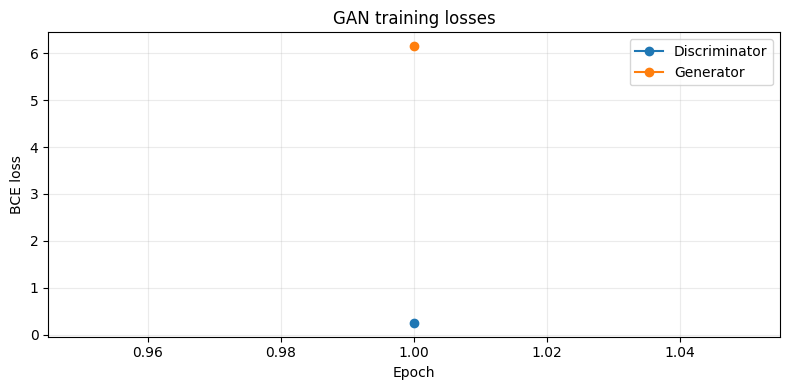

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS + 1), loss_history_D, marker="o", label="Discriminator")
plt.plot(range(1, N_EPOCHS + 1), loss_history_G, marker="o", label="Generator")
plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("GAN training losses")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

## 5. 加载模型并生成 100 张动漫人脸

下面重新加载 Generator checkpoint，生成 100 张图片，保存到 `output`，并打包为课件中的 `images.tgz`。

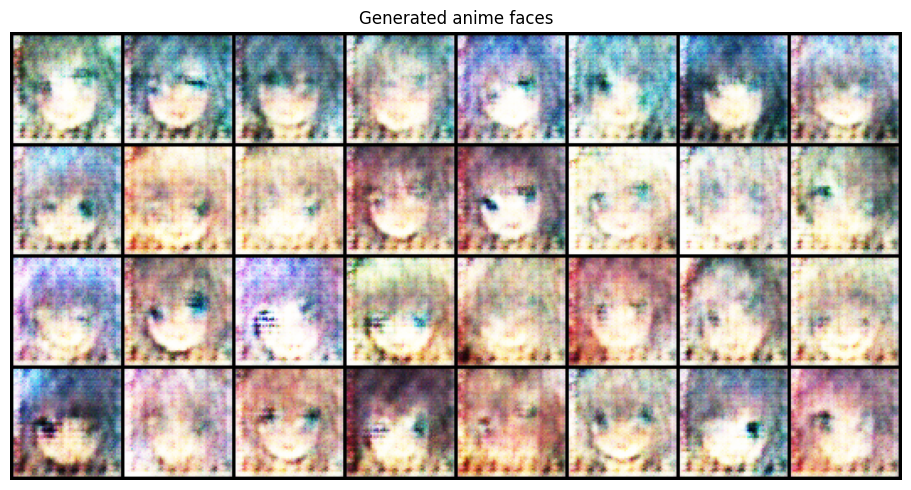

生成图片目录: /Users/bob.li/Code/DL-ZJU/lab7-1/outputs/output
100 张总览: /Users/bob.li/Code/DL-ZJU/lab7-1/outputs/logs/result.jpg
压缩包: /Users/bob.li/Code/DL-ZJU/lab7-1/outputs/images.tgz


In [13]:
def load_state_dict_safely(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=device)

generator = Generator(Z_DIM, MODEL_DIM).to(DEVICE)
generator.load_state_dict(load_state_dict_safely(CKPT_DIR / "G.pth", DEVICE))
generator.eval()

same_seeds(SEED + 1)
with torch.no_grad():
    final_noise = torch.randn(100, Z_DIM, device=DEVICE)
    generated_images = ((generator(final_noise) + 1) / 2).cpu().clamp(0, 1)

result_path = LOG_DIR / "result.jpg"
save_image(generated_images, result_path, nrow=10)
for index, image in enumerate(generated_images, start=1):
    save_image(image, FINAL_DIR / f"{index}.jpg")

archive_path = OUTPUT_DIR / "images.tgz"
with tarfile.open(archive_path, "w:gz") as archive:
    for image_path in sorted(FINAL_DIR.glob("*.jpg"), key=lambda path: int(path.stem)):
        archive.add(image_path, arcname=image_path.name)

grid = make_grid(generated_images[:32], nrow=8)
plt.figure(figsize=(10, 5))
plt.imshow(grid.permute(1, 2, 0))
plt.axis("off")
plt.title("Generated anime faces")
plt.tight_layout()
plt.show()
plt.close()

print("生成图片目录:", FINAL_DIR)
print("100 张总览:", result_path)
print("压缩包:", archive_path)

## 6. 实验结果检查

出现全部通过提示，即表明 Notebook 已完成数据读取、模型构建、训练、checkpoint 保存和 100 张动漫人脸导出。

In [14]:
output_images = sorted(FINAL_DIR.glob("*.jpg"))
assert len(output_images) == 100
assert all(path.stat().st_size > 0 for path in output_images)
assert (CKPT_DIR / "G.pth").exists()
assert (CKPT_DIR / "D.pth").exists()
assert result_path.exists() and archive_path.exists()
assert generated_images.shape == (100, 3, 64, 64)
assert torch.isfinite(generated_images).all()

with tarfile.open(archive_path, "r:gz") as archive:
    archived_jpgs = [name for name in archive.getnames() if name.lower().endswith(".jpg")]
assert len(archived_jpgs) == 100

print("✅ Lab 7-1 全部检查通过")
print({
    "training_images": len(dataset),
    "epochs": N_EPOCHS,
    "final_loss_D": loss_history_D[-1],
    "final_loss_G": loss_history_G[-1],
    "generated_images": len(output_images),
})

✅ Lab 7-1 全部检查通过
{'training_images': 71314, 'epochs': 1, 'final_loss_D': 0.2528714751188319, 'final_loss_G': 6.148726995158238, 'generated_images': 100}
